## 📊 Análisis de Abandono de Clientes (Churn)

### AndesLink Servicios Digitales S.A.

#### 1. Problema de Negocio:

AndesLink Servicios Digitales S.A. enfrenta una creciente pérdida de clientes (churn), lo cual impacta directamente en los ingresos operativos y eleva los costos de adquisición de nuevos usuarios.

Objetivo: Identificar los factores clave que impulsan esta deserción para diseñar estrategias de retención efectivas y personalizadas.

Variable Objetivo (churn):

1: El cliente abandonó el servicio.

0: El cliente permanece activo.

### 2. Configuración del Entorno y Librerías
En esta sección cargamos las herramientas necesarias para la manipulación de datos, visualización y preprocesamiento.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

### 3. Carga del Conjunto de Datos
Importamos los datos crudos desde el archivo CSV para comenzar con la exploración inicial.

In [ ]:
data = pd.read_csv('../data/raw/churn_sintetico.csv')
df = pd.DataFrame(data)
df

,tenure_months,monthly_charge,total_charges,support_tickets,late_payments,avg_monthly_usage_gb,contract_type,payment_method,internet_service,has_streaming,has_security_pack,num_products,region,customer_age,is_promo,churn
0,7,58.23,326.50,2,1,81.83,mensual,transferencia,cable,0,1,3,centro,53,1,1
1,56,56.75,3154.21,0,2,96.52,anual,debito,fibra,0,0,4,centro,53,0,0
2,48,78.84,3864.31,3,2,93.60,bianual,efectivo,movil,1,1,4,centro,73,1,1
3,32,79.74,2511.40,0,0,28.95,bianual,debito,movil,0,1,4,norte,25,0,1
4,32,55.37,1735.51,3,0,126.90,anual,efectivo,fibra,1,0,2,oeste,61,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,16,57.37,1002.70,1,1,46.59,mensual,debito,movil,0,0,1,centro,25,0,1
4996,54,74.45,4070.99,1,1,196.65,anual,debito,movil,0,1,4,sur,19,0,0
4997,60,44.96,2679.98,1,0,87.63,mensual,transferencia,fibra,1,0,2,centro,21,0,0
4998,49,63.03,3153.70,2,2,113.46,mensual,credito,cable,1,1,1,norte,65,0,1


### 4. Inspección y Calidad de Datos

Antes del análisis, validamos la integridad de la información buscando duplicados o valores nulos.

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df.isnull().sum()

tenure_months           0
monthly_charge          0
total_charges           0
support_tickets         0
late_payments           0
avg_monthly_usage_gb    0
contract_type           0
payment_method          0
internet_service        0
has_streaming           0
has_security_pack       0
num_products            0
region                  0
customer_age            0
is_promo                0
churn                   0
dtype: int64

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tenure_months         5000 non-null   int64  
 1   monthly_charge        5000 non-null   float64
 2   total_charges         5000 non-null   float64
 3   support_tickets       5000 non-null   int64  
 4   late_payments         5000 non-null   int64  
 5   avg_monthly_usage_gb  5000 non-null   float64
 6   contract_type         5000 non-null   object 
 7   payment_method        5000 non-null   object 
 8   internet_service      5000 non-null   object 
 9   has_streaming         5000 non-null   int64  
 10  has_security_pack     5000 non-null   int64  
 11  num_products          5000 non-null   int64  
 12  region                5000 non-null   object 
 13  customer_age          5000 non-null   int64  
 14  is_promo              5000 non-null   int64  
 15  churn                

In [41]:
df.describe()

,tenure_months,monthly_charge,total_charges,support_tickets,late_payments,avg_monthly_usage_gb,has_streaming,has_security_pack,num_products,customer_age,is_promo,churn
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,36.407200,65.273282,2371.156582,1.710400,0.69700,120.528458,0.668000,0.539800,2.516400,47.825800,0.386200,0.340400
std,20.839776,17.963425,1555.943231,1.304788,0.84388,49.745297,0.470978,0.498463,1.111746,17.615684,0.486926,0.473891
min,1.000000,15.000000,50.000000,0.000000,0.00000,5.000000,0.000000,0.000000,1.000000,18.000000,0.000000,0.000000
25%,18.000000,53.060000,1100.357500,1.000000,0.00000,86.505000,0.000000,0.000000,2.000000,32.000000,0.000000,0.000000
50%,36.000000,64.965000,2162.810000,2.000000,0.00000,120.030000,1.000000,1.000000,3.000000,48.000000,0.000000,0.000000
75%,55.000000,77.362500,3432.657500,2.000000,1.00000,154.100000,1.000000,1.000000,4.000000,63.000000,1.000000,1.000000
max,72.000000,127.170000,9083.060000,8.000000,5.00000,324.400000,1.000000,1.000000,4.000000,78.000000,1.000000,1.000000


#### Resumen del Dataset

Registros: 5,000

##### Columnas
Demográficas: customer_age, region.

Servicio/Uso: tenure_months, avg_monthly_usage_gb, internet_service.

Financieras: monthly_charge, total_charges, late_payments.

##### Limitaciones 

El dataset es sintetico, por lo que no refleja correctamente la realidad de un servicio y puede afectar al momento de hacer analisis de los mismos datos y para entrenar el modelo correctamente.

#### 5. Visualización de Factores Clave
Analizamos visualmente cómo influyen ciertas variables en la decisión del cliente de abandonar o permanecer

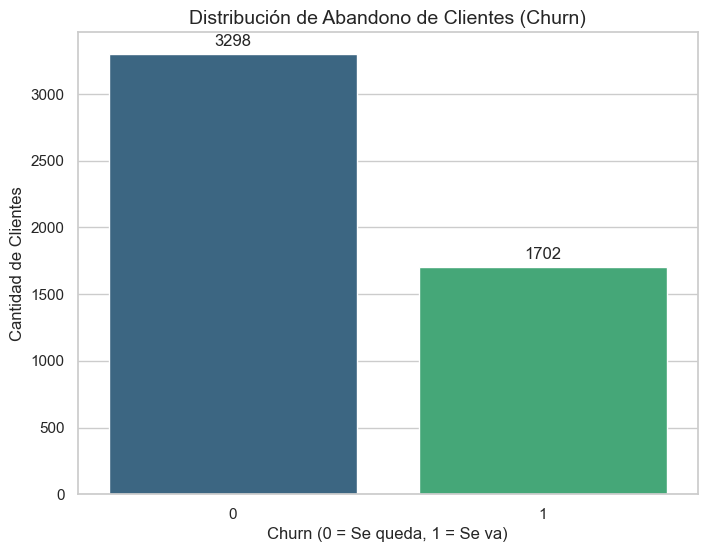

In [42]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='churn', hue='churn', palette='viridis', legend=False)

plt.title('Distribución de Abandono de Clientes (Churn)', fontsize=14)
plt.xlabel('Churn (0 = Se queda, 1 = Se va)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)


for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.show()

El cuadro refleja que el 34% de los usuarios dejan el servicio

In [43]:
columnas_quitar = ['has_streaming', 'has_security_pack', 'is_promo', 'contract_type', 'payment_method', 'internet_service', 'has_streaming', 'region',	'is_promo',	'churn']
df1 = df.drop(columns= columnas_quitar)

In [44]:
df1

,tenure_months,monthly_charge,total_charges,support_tickets,late_payments,avg_monthly_usage_gb,num_products,customer_age
0,7,58.23,326.50,2,1,81.83,3,53
1,56,56.75,3154.21,0,2,96.52,4,53
2,48,78.84,3864.31,3,2,93.60,4,73
3,32,79.74,2511.40,0,0,28.95,4,25
4,32,55.37,1735.51,3,0,126.90,2,61
...,...,...,...,...,...,...,...,...
4995,16,57.37,1002.70,1,1,46.59,1,25
4996,54,74.45,4070.99,1,1,196.65,4,19
4997,60,44.96,2679.98,1,0,87.63,2,21
4998,49,63.03,3153.70,2,2,113.46,1,65


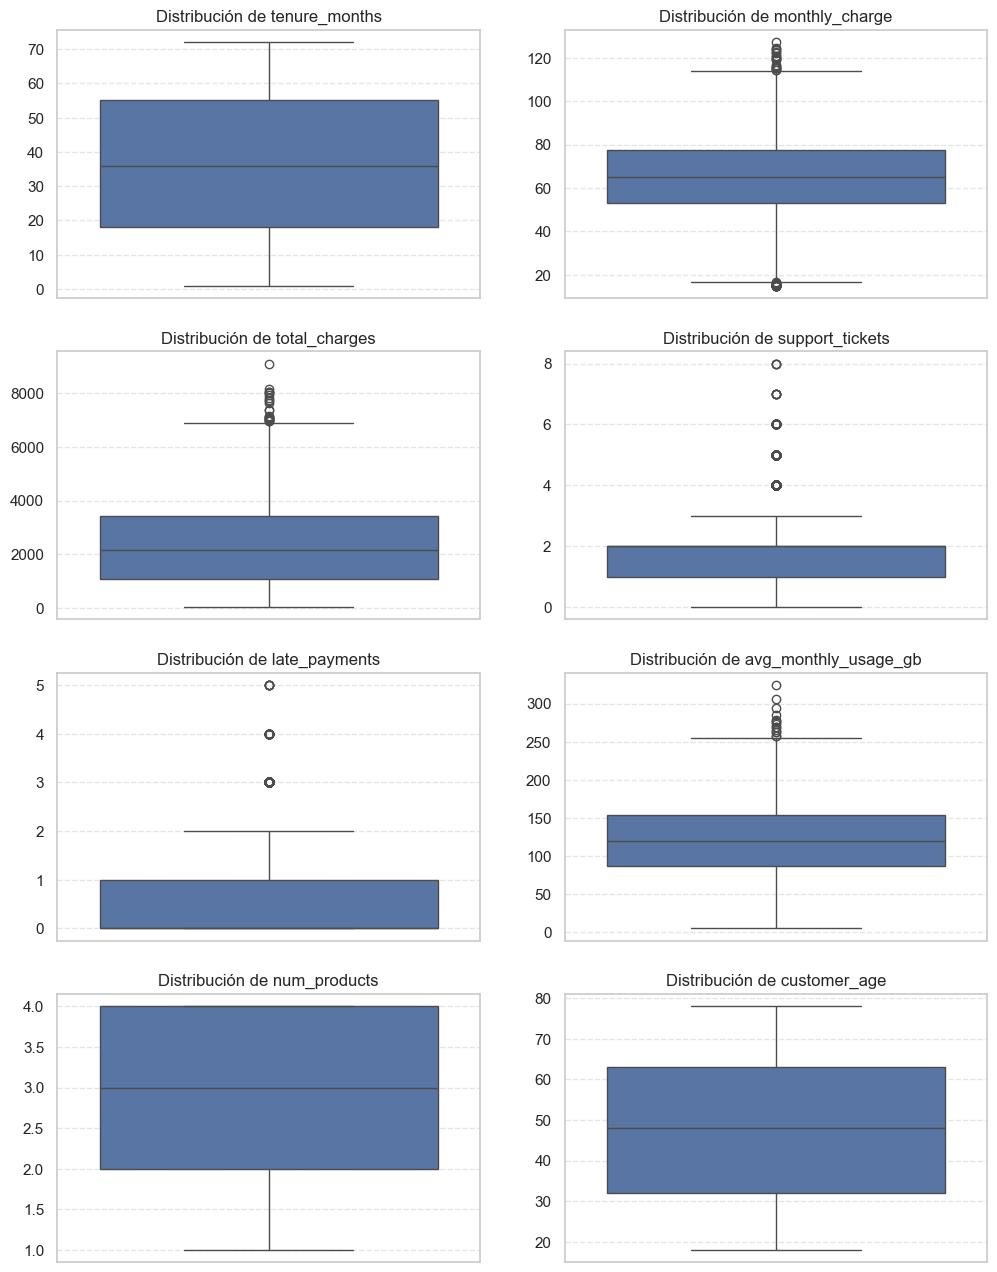

In [45]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 16))

axes = axes.flatten()

for i, col in enumerate(df1.columns):
    sns.boxplot(y=df1[col], ax=axes[i])
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_ylabel('')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [46]:
columnas = ['tenure_months', 'monthly_charge', 'total_charges' , 'support_tickets', 'late_payments', 'avg_monthly_usage_gb', 'num_products' , 'customer_age']

In [47]:
for col in columnas:

    q1 = round(df[col].quantile(0.25),2)
    q3 = round(df[col].quantile(0.75),2)

    iqr = q3 - q1
    limiteInferior = q1 - (1.5 * iqr)
    limiteSuperior = q3 + (1.5 * iqr)
    print(f"Para la columna {col} el limite inferior es: {limiteInferior}, y el superior es {limiteSuperior}")

Para la columna tenure_months el limite inferior es: -37.5, y el superior es 110.5
Para la columna monthly_charge el limite inferior es: 16.610000000000007, y el superior es 113.81
Para la columna total_charges el limite inferior es: -2398.09, y el superior es 6931.110000000001
Para la columna support_tickets el limite inferior es: -0.5, y el superior es 3.5
Para la columna late_payments el limite inferior es: -1.5, y el superior es 2.5
Para la columna avg_monthly_usage_gb el limite inferior es: -14.899999999999991, y el superior es 255.5
Para la columna num_products el limite inferior es: -1.0, y el superior es 7.0
Para la columna customer_age el limite inferior es: -14.5, y el superior es 109.5


In [48]:
df1.describe()

,tenure_months,monthly_charge,total_charges,support_tickets,late_payments,avg_monthly_usage_gb,num_products,customer_age
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000
mean,36.407200,65.273282,2371.156582,1.710400,0.69700,120.528458,2.516400,47.825800
std,20.839776,17.963425,1555.943231,1.304788,0.84388,49.745297,1.111746,17.615684
min,1.000000,15.000000,50.000000,0.000000,0.00000,5.000000,1.000000,18.000000
25%,18.000000,53.060000,1100.357500,1.000000,0.00000,86.505000,2.000000,32.000000
50%,36.000000,64.965000,2162.810000,2.000000,0.00000,120.030000,3.000000,48.000000
75%,55.000000,77.362500,3432.657500,2.000000,1.00000,154.100000,4.000000,63.000000
max,72.000000,127.170000,9083.060000,8.000000,5.00000,324.400000,4.000000,78.000000


#### Análisis de Comportamiento por Tipo de Contrato

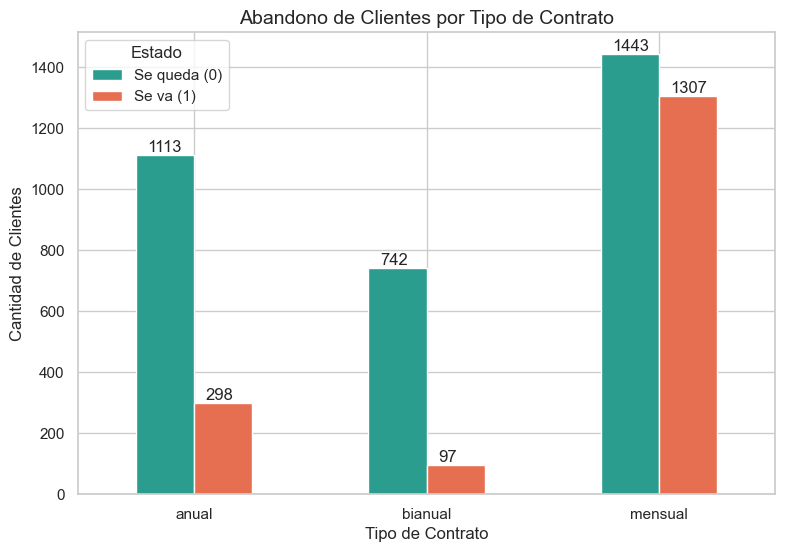

In [49]:
contract_churn = df.groupby(['contract_type', 'churn']).size().unstack()

ax = contract_churn.plot(kind='bar', stacked=False, figsize=(9, 6), color=['#2a9d8f', '#e76f51'])

plt.title('Abandono de Clientes por Tipo de Contrato', fontsize=14)
plt.xlabel('Tipo de Contrato', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.legend(['Se queda (0)', 'Se va (1)'], title='Estado')
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + 0.05, p.get_height() + 10))

plt.show()

#### 6. Finalizacion EDA y guardado de la nueva fuente de datos trabajada

In [ ]:
import os
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/churn_sintetico_EDA.csv', index=False)